In [1]:
suppressMessages(library(ArchR))
suppressMessages(library(ggplot2))
suppressMessages(library(cowplot))
suppressMessages(library(rtracklayer))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(BSgenome.Mmusculus.UCSC.mm39))

In [2]:
addArchRThreads(threads = 32) 

Setting default number of Parallel threads to 32.



In [3]:
in_dir = '../../results/04_single_cell_access_atac/09_merge_fragment'
out_dir = '../../results/04_single_cell_access_atac/13_create_archr_project'

# create output directory
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}

In [4]:
# create a custom gene annotation from GTF
gtf <- import("../../data/refdata-cellranger-arc-GRCm39-2024-A/genes/genes.gtf.gz")
genes_gr <- gtf[gtf$type == "gene"]
genes_gr$symbol <- genes_gr$gene_name
mcols(genes_gr) <- mcols(genes_gr)[, c("gene_id", "symbol")]

# create exon annotation
exons_gr <- gtf[gtf$type == "exon"]
exons_gr$symbol <- exons_gr$gene_name
mcols(exons_gr) <- mcols(exons_gr)[, c("exon_id", "symbol")]

# get TSS
tss_gr <- import("../../data/refdata-cellranger-arc-GRCm39-2024-A/regions/tss.bed")

geneAnnotation <- createGeneAnnotation(
  TSS = tss_gr, 
  exons = exons_gr, 
  genes = genes_gr
)

genomeAnnotation <- createGenomeAnnotation(genome = BSgenome.Mmusculus.UCSC.mm39)

Getting genome..

Attempting to infer chromSizes..

Attempting to infer blacklist..

Blacklist not downloaded! Continuing without, be careful for downstream biases..



In [5]:
inputFiles <- c("mouse" = glue::glue("{in_dir}/merged.atac.tsv.gz"))
df_barcodes <- read.csv("../../data/10xGenomics/737K-cratac-v1.txt", header = FALSE)

In [6]:
ArrowFiles <- createArrowFiles(
    inputFiles = inputFiles,
    sampleNames = names(inputFiles),
    minTSS = 4, #Dont set this too high because you can always increase later
    minFrags = 1000, 
    maxFrags = 1e7,
    validBarcodes = df_barcodes$V1,
    geneAnnotation = geneAnnotation,
    genomeAnnotation = genomeAnnotation,
    addTileMat = TRUE,
    addGeneScoreMat = TRUE,
    force=TRUE
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : JH584299.1,GL456211.1,GL456221.1,JH584297.1,JH584296.1,GL456354.1,JH584298.1,GL456219.1,GL456210.1,JH584303.1,GL456212.1,JH584304.1,JH584295.1

ArchR logging to : ArchRLogs/ArchR-createArrows-3317c2c0e4a2e-Date-2026-01-16_Time-16-43-44.54932.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

subThreading Disabled since ArchRLocking is TRUE see `addArchRLocking`

2026-01-16 16:43:44.989523 : Batch Execution w/ safelapply!, 0 mins elapsed.

(mouse : 1 of 1) De

In [7]:
proj <- ArchRProject(
  ArrowFiles = ArrowFiles, 
  outputDirectory = out_dir,
  copyArrows = TRUE,
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : JH584299.1,GL456211.1,GL456221.1,JH584297.1,JH584296.1,GL456354.1,JH584298.1,GL456219.1,GL456210.1,JH584303.1,GL456212.1,JH584304.1,JH584295.1

Validating Arrows...

Getting SampleNames...

1 


Copying ArrowFiles to Ouptut Directory! If you want to save disk space set copyArrows = FALSE

1 


Getting Cell Metadata...

1 


Merging Cell Metadata...

Initializing ArchRProject...


                                                   / |
                                                 /    \
        

In [8]:
proj


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /data/pinello/PROJECTS/2025_06_ZL_ACCESS/results/35_scACCESS_mouseAirwayCell/13_create_archr_project 
samples(1): mouse
sampleColData names(1): ArrowFiles
cellColData names(11): Sample TSSEnrichment ... nFrags nDiFrags
numberOfCells(1): 2024
medianTSS(1): 12.572
medianFrags(1): 5788.5

ArchR logging to : ArchRLogs/ArchR-plotTSSEnrichment-3317c3f62af23-Date-2026-01-16_Time-16-55-57.180561.log
If there is an issue, please report to github with logFile!

subThreading Disabled since ArchRLocking is TRUE see `addArchRLocking`

2026-01-16 16:55:57.716741 : mouse Computing TSS (1 of 1)!, 0.009 mins elapsed.

2026-01-16 16:56:24.741968 : mouse Finished Computing TSS (1 of 1)!, 0.459 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-plotTSSEnrichment-3317c3f62af23-Date-2026-01-16_Time-16-55-57.180561.log



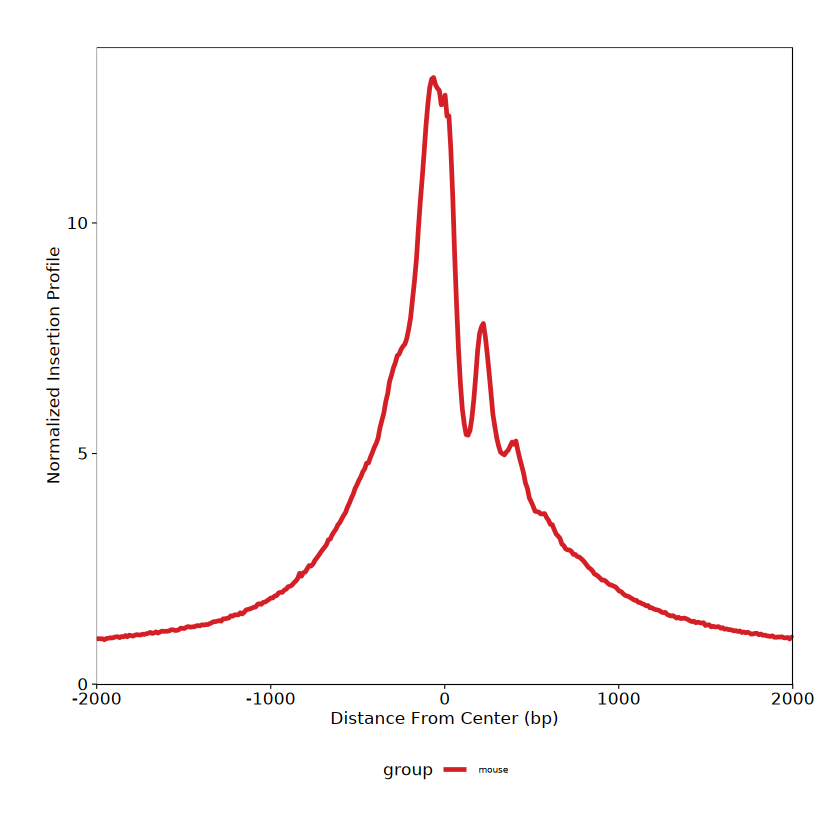

In [9]:
 plotTSSEnrichment(ArchRProj = proj)

In [10]:
mean(proj@cellColData$nFrags)

[1] 11228.17

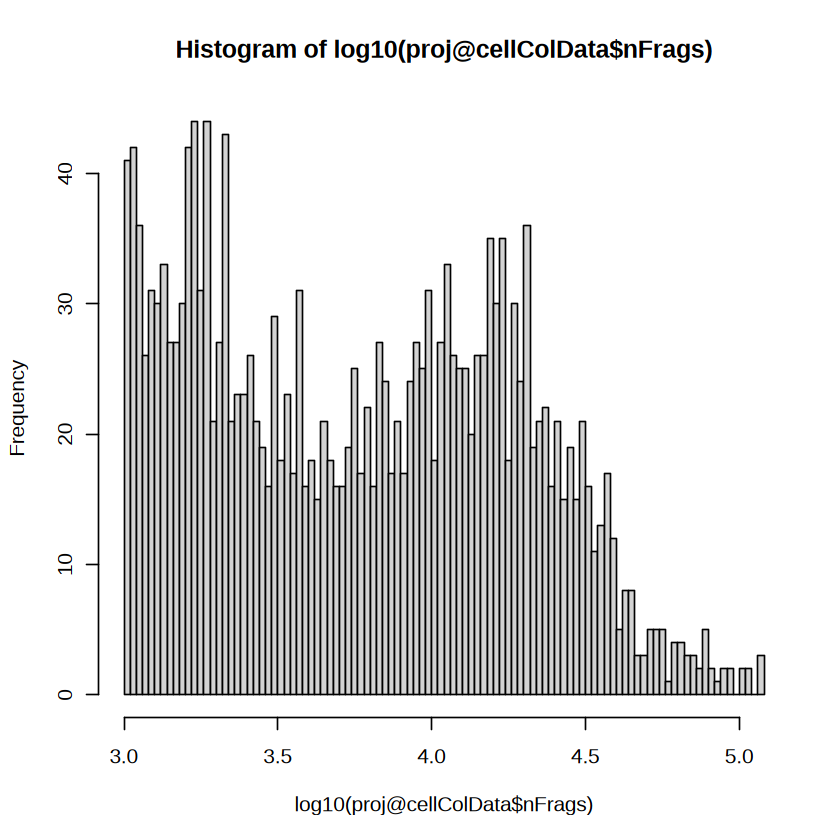

In [11]:
hist(log10(proj@cellColData$nFrags), breaks=100)

In [12]:
proj <- addDoubletScores(proj)

ArchR logging to : ArchRLogs/ArchR-addDoubletScores-3317c7e52f042-Date-2026-01-16_Time-16-56-25.217088.log
If there is an issue, please report to github with logFile!

2026-01-16 16:56:25.392652 : Batch Execution w/ safelapply!, 0 mins elapsed.

2026-01-16 16:56:25.400647 : mouse (1 of 1) :  Computing Doublet Statistics, 0 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

Biased Clusters : 
Cluster5 


mouse (1 of 1) : UMAP Projection R^2 = 0.94202

mouse (1 of 1) : UMAP Projection R^2 = 0.94202

ArchR logging successful to : ArchRLogs/ArchR-addDoubletScores-3317c7e52f042-Date-2026-01-16_Time-16-56-25.217088.log



In [13]:
proj <- addGroupCoverages(ArchRProj = proj,
                          groupBy = "Sample",
                          minCells = nrow(proj@cellColData),
                          maxCells = 2 * nrow(proj@cellColData),
                          maxReplicates = 1,
                          maxFragments = 1e10,
                          sampleRatio = 1.0,
                          force = TRUE)

proj <- addReproduciblePeakSet(
    ArchRProj = proj, 
    groupBy = "Sample", 
    cutOff = 0.01,
    pathToMacs2 = "/data/pinello/SHARED_SOFTWARE/envs/zl002_envs/zl_macs2/bin/macs2",
    plot = FALSE,
    genomeSize = "mm",
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation
)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-3317cfe93ab1-Date-2026-01-16_Time-16-57-31.679026.log
If there is an issue, please report to github with logFile!

Skipping validation of empty chromosomes since `force` = TRUE!

mouse (1 of 1) : CellGroups N = 1

2026-01-16 16:57:32.149454 : Creating Coverage Files!, 0.008 mins elapsed.

2026-01-16 16:57:32.152473 : Batch Execution w/ safelapply!, 0.008 mins elapsed.

2026-01-16 16:57:32.165666 : Group mouse._.Rep1 (1 of 1) : Creating Group Coverage File : mouse._.Rep1.insertions.coverage.h5, 0.008 mins elapsed.

Number of Cells = 2024

Coverage File Exists!

Added Coverage Group

Added Metadata Group

Added ArrowCoverage Class

Added Coverage/Info

Added Coverage/Info/CellNames

2026-01-16 16:58:20.186046 : Adding Kmer Bias to Coverage Files!, 0.808 mins elapsed.

Completed Kmer Bias Calculation

Adding Kmer Bias (1 of 1)

2026-01-16 16:58:28.60649 : Finished Creation of Coverage Files!, 0.949 mins elapsed.

ArchR logging successfu

In [14]:
proj <- addPeakMatrix(proj, binarize=TRUE)

ArchR logging to : ArchRLogs/ArchR-addPeakMatrix-3317c70103c5b-Date-2026-01-16_Time-17-01-29.493055.log
If there is an issue, please report to github with logFile!

2026-01-16 17:01:29.619944 : Batch Execution w/ safelapply!, 0 mins elapsed.

2026-01-16 17:01:30.310559 : Adding mouse to PeakMatrix for Chr (1 of 20)!, 0.01 mins elapsed.

2026-01-16 17:01:34.273483 : Adding mouse to PeakMatrix for Chr (2 of 20)!, 0.076 mins elapsed.

2026-01-16 17:01:37.692368 : Adding mouse to PeakMatrix for Chr (3 of 20)!, 0.133 mins elapsed.

2026-01-16 17:01:40.90269 : Adding mouse to PeakMatrix for Chr (4 of 20)!, 0.187 mins elapsed.

2026-01-16 17:01:44.105295 : Adding mouse to PeakMatrix for Chr (5 of 20)!, 0.24 mins elapsed.

2026-01-16 17:01:47.254797 : Adding mouse to PeakMatrix for Chr (6 of 20)!, 0.292 mins elapsed.

2026-01-16 17:01:50.333006 : Adding mouse to PeakMatrix for Chr (7 of 20)!, 0.344 mins elapsed.

2026-01-16 17:01:53.530074 : Adding mouse to PeakMatrix for Chr (8 of 20)!, 0.397

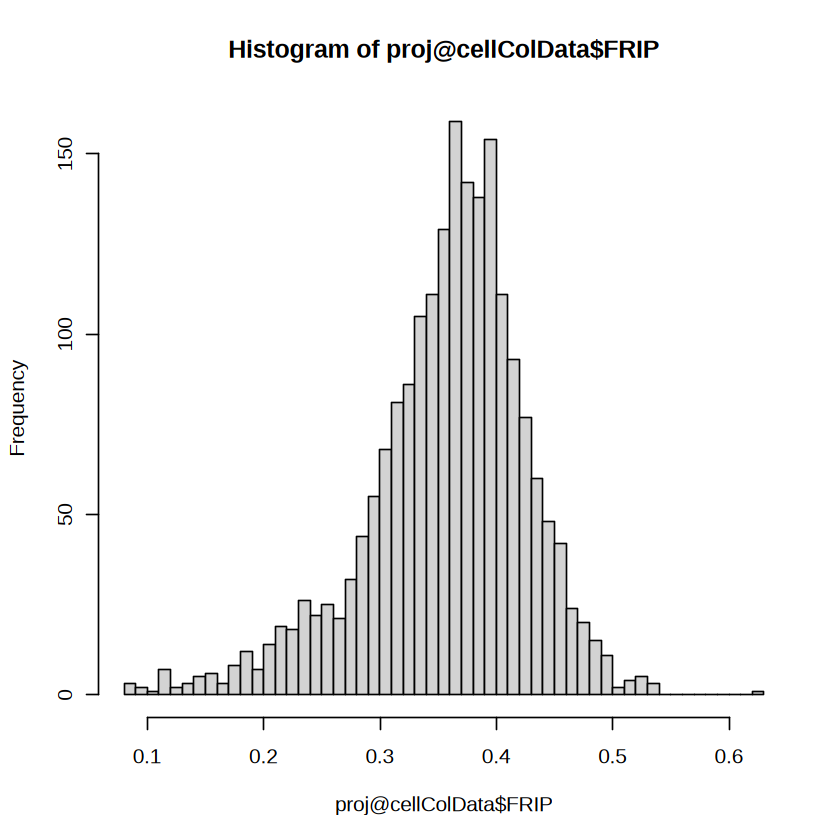

In [15]:
hist(proj@cellColData$FRIP, breaks=50)

In [16]:
## save peak matrix
peakMatrix <- getMatrixFromProject(proj,
                                   useMatrix = "PeakMatrix",
                                   binarize = TRUE)

counts <- peakMatrix@assays@data$PeakMatrix
df_ranger <- as.data.frame(peakMatrix@rowRanges@ranges)

rownames(counts) <- paste(peakMatrix@rowRanges@seqnames,
                          df_ranger$start, df_ranger$end, sep = "_") 

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-3317c50dcfcd-Date-2026-01-16_Time-17-02-31.939375.log
If there is an issue, please report to github with logFile!

2026-01-16 17:02:35.978022 : Organizing colData, 0.067 mins elapsed.

2026-01-16 17:02:35.982628 : Organizing rowData, 0.067 mins elapsed.

2026-01-16 17:02:35.987705 : Organizing rowRanges, 0.067 mins elapsed.

2026-01-16 17:02:35.996778 : Organizing Assays (1 of 1), 0.068 mins elapsed.

2026-01-16 17:02:36.003675 : Constructing SummarizedExperiment, 0.068 mins elapsed.

2026-01-16 17:02:37.7348 : Finished Matrix Creation, 0.097 mins elapsed.



In [17]:
dim(counts)

[1] 139613   2024

In [18]:
saveRDS(counts, file = glue::glue("{out_dir}/PeakMatrix.Rds"))

In [19]:
## save gene matrix
atac <- getMatrixFromProject(ArchRProj = proj,
                             useMatrix = "GeneScoreMatrix")
gene_score <- atac@assays@data$GeneScoreMatrix
rownames(gene_score) <- atac@elementMetadata$name

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-3317c3857c55b-Date-2026-01-16_Time-17-02-43.026668.log
If there is an issue, please report to github with logFile!

2026-01-16 17:02:53.022833 : Organizing colData, 0.167 mins elapsed.

2026-01-16 17:02:53.026882 : Organizing rowData, 0.167 mins elapsed.

2026-01-16 17:02:53.030636 : Organizing rowRanges, 0.167 mins elapsed.

2026-01-16 17:02:53.036592 : Organizing Assays (1 of 1), 0.167 mins elapsed.

2026-01-16 17:02:53.078892 : Constructing SummarizedExperiment, 0.168 mins elapsed.

2026-01-16 17:02:54.264539 : Finished Matrix Creation, 0.187 mins elapsed.



In [20]:
saveRDS(gene_score, file = glue::glue("{out_dir}/GeneScoreMatrix.Rds"))

In [21]:
## Save data
saveArchRProject(ArchRProj = proj, 
                 load = FALSE)

Saving ArchRProject...



In [22]:
## Session information
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 20.04.6 LTS

Matrix products: default
BLAS/LAPACK: /data/pinello/SHARED_SOFTWARE/envs/zl002_envs/zl_access/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

Random number generation:
 RNG:     L'Ecuyer-CMRG 
 Normal:  Inversion 
 Sample:  Rejection 
 
locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
 [1] parallel  stats4    grid      stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] nabor_0.5.0                        future_1.58.0                     
 [3] Rsamtool